In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# Bayesian Rule Mining

Building on association rule mining (notebook 07), this notebook applies Bayesian statistical measures to evaluate and refine discovered rules. We also learn a Bayesian Network structure to uncover directional dependencies between product categories.

In [49]:
data_copy = pd.read_csv('../data/data_unencoded.csv')

purchases_by_customer = data_copy.groupby('Survey ResponseID')['Category'].apply(list).tolist()
purchases_by_customer

[['FLASH_MEMORY',
  'HEADPHONES',
  'DISHWARE_BOWL',
  'SHAVING_AGENT',
  'COMPUTER_PROCESSOR',
  'ELECTRONIC_CABLE',
  'AMAZON_TABLET',
  'APPAREL_BELT',
  'PORTABLE_ELECTRONIC_DEVICE_STAND',
  'HEADPHONES',
  'IMMERSION_HEATER',
  'HEADPHONES',
  'FLASH_MEMORY',
  'BODY_LUBRICANT',
  'HEADPHONES',
  'INPUT_MOUSE',
  'HEADPHONES',
  'CELLULAR_PHONE_CASE',
  'BODY_POSITIONER',
  'HANDBAG',
  'UNDERPANTS',
  'UNDERPANTS',
  'TAPE_MEASURE',
  'AMAZON_TABLET_ACCESSORY',
  'COMPUTER_DRIVE_OR_STORAGE',
  'TOOTH_CLEANING_AGENT',
  'TOILET_PAPER',
  'MOUTHWASH',
  'ELECTRONIC_CABLE',
  'SCREWDRIVER',
  'EDIBLE_OIL_VEGETABLE',
  'EDIBLE_OIL_VEGETABLE',
  'SIM_CARD',
  'BED_FRAME',
  'HERB',
  'MEAT',
  'DAIRY_BASED_BUTTER',
  'DAIRY_BASED_CHEESE',
  'JERKY',
  'BODY_LUBRICANT',
  'SEXUAL_STIMULATION_DEVICE',
  'FLASH_MEMORY',
  'BODY_LUBRICANT',
  'FLASH_MEMORY',
  'EDIBLE_OIL_VEGETABLE',
  'EDIBLE_OIL_VEGETABLE',
  'SEXUAL_STIMULATION_DEVICE',
  'SEXUAL_STIMULATION_DEVICE',
  'BODY_LUBRICANT'

In [50]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

encoder = TransactionEncoder()
encoding = encoder.fit_transform(purchases_by_customer)
transaction_data = pd.DataFrame(encoding, columns=encoder.columns_)

frequent_itemsets = apriori(transaction_data, min_support=0.5, use_colnames=True)

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5, num_itemsets=len(transaction_data.index))

In [51]:
#Creating a new column for Bayesian confidence
total_transactions = len(purchases_by_customer)

#Defining a smoothing parameter m (weight of the prior)
m = 2 

#Reconstructing the raw counts from support
count_X = rules['antecedent support'] * total_transactions
count_X_and_Y = rules['support'] * total_transactions
prior_Y = rules['consequent support'] # P(Y)

#Bayesian Confidence formula
rules['bayesian_confidence'] = (count_X_and_Y + m * prior_Y) / (count_X + m)

In [ ]:
#Calculating P(X|Y) and P(X|~Y)
#P(X|Y) = P(X and Y) / P(Y)
p_X_given_Y = rules['support'] / rules['consequent support']

#P(X|~Y) = P(X and ~Y) / P(~Y)
# P(X and ~Y) = P(X) - P(X and Y)
p_X_and_not_Y = rules['antecedent support'] - rules['support']
p_not_Y = 1 - rules['consequent support']
p_X_given_not_Y = p_X_and_not_Y / p_not_Y

#Kemeny-Oppenheim Measure - Evaluates the strength of a rule X to Y on a scale from -1 to 1
rules['kemeny_oppenheim'] = (p_X_given_Y - p_X_given_not_Y) / (p_X_given_Y + p_X_given_not_Y)

#Filtering rules by positive confirmation
bayesian_rules = rules[rules['kemeny_oppenheim'] > 0.5].sort_values(by='kemeny_oppenheim', ascending=False)

#This will all help evaluate how much the presence of X changes our belief in Y

In [53]:
from pgmpy.estimators import HillClimbSearch, BIC

#Encoding the transactions
te = TransactionEncoder()
te_ary = te.fit(purchases_by_customer).transform(purchases_by_customer)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

#Searching for the Bayesian Network structure
frequent_categories = df_encoded.sum().sort_values(ascending=False).head(20).index
df_subset = df_encoded[frequent_categories]

hc = HillClimbSearch(df_subset)
best_model = hc.estimate(scoring_method=BIC(df_subset))

#Viewing the discovered dependencies (aka the edges)
print(best_model.edges())

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'ABIS_BOOK': 'N', 'SHIRT': 'N', 'ELECTRONIC_CABLE': 'N', 'HEADPHONES': 'N', 'CELLULAR_PHONE_CASE': 'N', 'HEALTH_PERSONAL_CARE': 'N', 'CHARGING_ADAPTER': 'N', 'SHOES': 'N', 'PANTS': 'N', 'NUTRITIONAL_SUPPLEMENT': 'N', 'SKIN_MOISTURIZER': 'N', 'BATTERY': 'N', 'SCREEN_PROTECTOR': 'N', 'SOCKS': 'N', 'PORTABLE_ELECTRONIC_DEVICE_COVER': 'N', 'HOME': 'N', 'MEDICATION': 'N', 'BEAUTY': 'N', 'DRINKING_CUP': 'N', 'TOYS_AND_GAMES': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'ABIS_BOOK': 'N', 'SHIRT': 'N', 'ELECTRONIC_CABLE': 'N', 'HEADPHONES': 'N', 'CELLULAR_PHONE_CASE': 'N', 'HEALTH_PERSONAL_CARE': 'N', 'CHARGING_ADAPTER': 'N', 'SHOES': 'N', 'PANTS': 'N', 'NUTRITIONAL_SUPPLEMENT': 'N', 'SKIN_MOISTURIZER': 'N', 'BATTERY': 'N', 'SCREEN_PROTECTOR': 'N', 'SOCKS': 'N', 'PORTABLE_ELECTRONIC_DEVICE_COVER': 'N', 'HOME': 'N', 'MEDICAT

[('SHIRT', 'PANTS'), ('SHIRT', 'SOCKS'), ('SHIRT', 'HEALTH_PERSONAL_CARE'), ('ELECTRONIC_CABLE', 'CHARGING_ADAPTER'), ('ELECTRONIC_CABLE', 'HEADPHONES'), ('HEADPHONES', 'NUTRITIONAL_SUPPLEMENT'), ('CELLULAR_PHONE_CASE', 'ELECTRONIC_CABLE'), ('CELLULAR_PHONE_CASE', 'PORTABLE_ELECTRONIC_DEVICE_COVER'), ('HEALTH_PERSONAL_CARE', 'MEDICATION'), ('HEALTH_PERSONAL_CARE', 'CELLULAR_PHONE_CASE'), ('HEALTH_PERSONAL_CARE', 'HOME'), ('HEALTH_PERSONAL_CARE', 'SCREEN_PROTECTOR'), ('CHARGING_ADAPTER', 'HEADPHONES'), ('SHOES', 'SCREEN_PROTECTOR'), ('PANTS', 'SOCKS'), ('PANTS', 'SHOES'), ('NUTRITIONAL_SUPPLEMENT', 'SKIN_MOISTURIZER'), ('SKIN_MOISTURIZER', 'BEAUTY'), ('SKIN_MOISTURIZER', 'DRINKING_CUP'), ('SCREEN_PROTECTOR', 'CELLULAR_PHONE_CASE'), ('SCREEN_PROTECTOR', 'PORTABLE_ELECTRONIC_DEVICE_COVER'), ('SCREEN_PROTECTOR', 'CHARGING_ADAPTER'), ('SOCKS', 'HEALTH_PERSONAL_CARE'), ('SOCKS', 'MEDICATION'), ('SOCKS', 'DRINKING_CUP'), ('SOCKS', 'SHOES'), ('SOCKS', 'ELECTRONIC_CABLE'), ('HOME', 'BATTERY'), 

## Bayesian Network Visualization

Visualize the learned network structure. Each edge represents a discovered directional dependency between product categories.

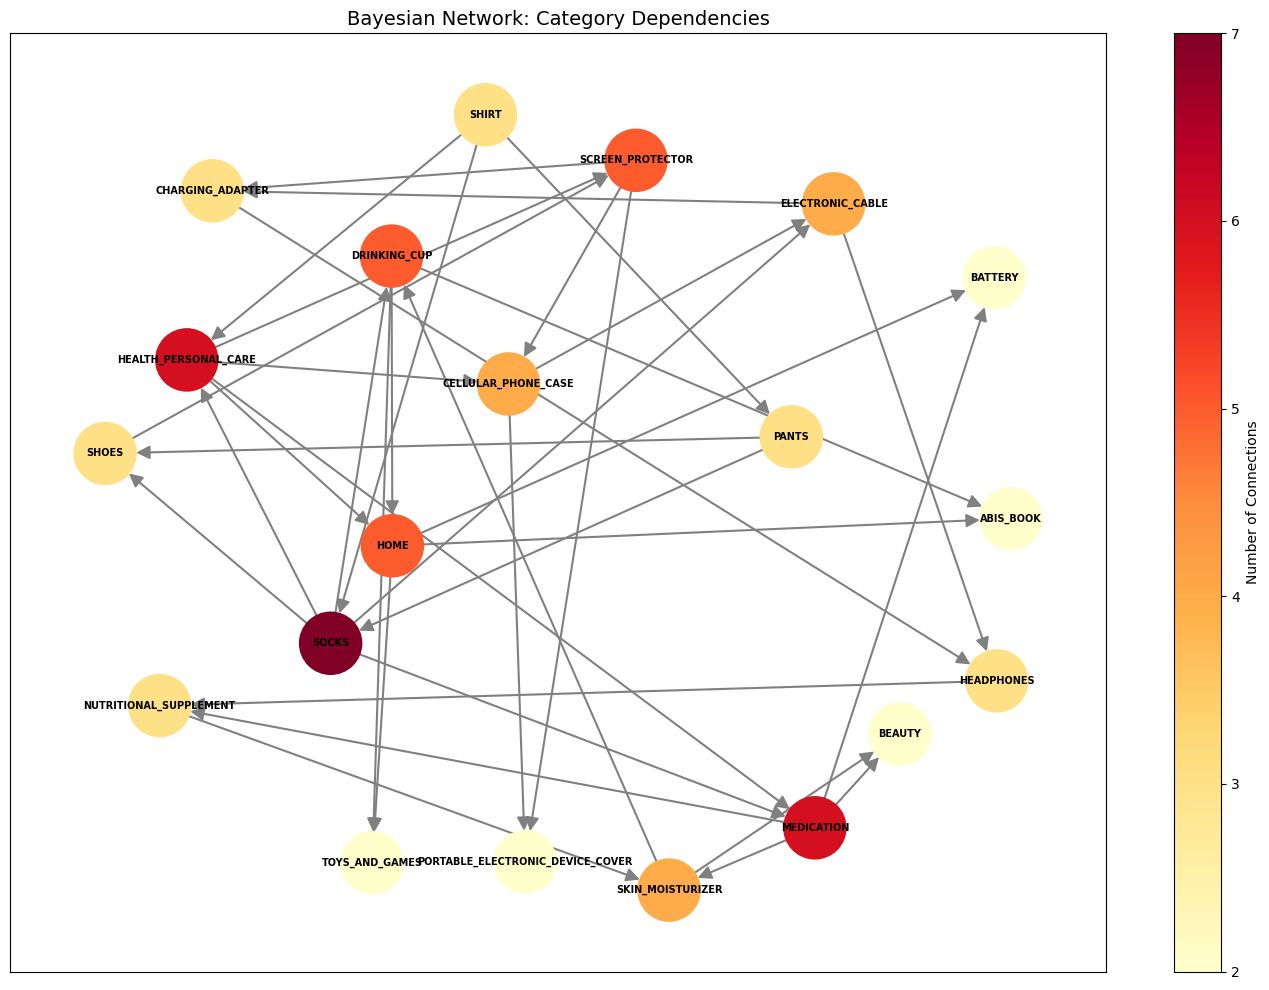

In [54]:
# Build a directed graph from the learned Bayesian Network edges
G = nx.DiGraph(best_model.edges())

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42, k=2)

# Shade nodes by number of connections (degree)
node_degrees = [G.degree(n) for n in G.nodes()]

nx.draw_networkx(
    G, pos, ax=ax,
    node_color=node_degrees,
    cmap=plt.cm.YlOrRd,
    node_size=2000,
    font_size=7,
    font_weight='bold',
    arrows=True,
    arrowsize=20,
    edge_color='gray',
    width=1.5
)

sm = plt.cm.ScalarMappable(cmap=plt.cm.YlOrRd, norm=plt.Normalize(vmin=min(node_degrees), vmax=max(node_degrees)))
sm.set_array([])
fig.colorbar(sm, ax=ax, label='Number of Connections')
ax.set_title('Bayesian Network: Category Dependencies', fontsize=14)
plt.tight_layout()
plt.show()

## Top Bayesian Rules

Display the association rules filtered by positive Kemeny-Oppenheim confirmation (> 0.5), showing which category pairings have the strongest Bayesian-adjusted evidence.

In [55]:
# Show the top Bayesian rules with key metrics
display_cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift',
                'bayesian_confidence', 'kemeny_oppenheim']
bayesian_rules[display_cols]

,antecedents,consequents,support,confidence,lift,bayesian_confidence,kemeny_oppenheim
40,frozenset({PANTS}),frozenset({SHIRT}),0.507659,0.895753,1.259566,0.894338,0.554557


## Conditional Probability Tables

Fit the Bayesian Network parameters and display conditional probability tables (CPTs) for the most connected categories. These show the probability of purchasing a category given its parent categories in the network.

In [56]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator

# Build and fit the Bayesian Network with learned structure
bn_model = DiscreteBayesianNetwork(best_model.edges())
bn_model.fit(df_subset, estimator=MaximumLikelihoodEstimator)

# Show CPTs for the 5 most connected nodes
node_degree = dict(G.degree())
top_nodes = sorted(node_degree, key=node_degree.get, reverse=True)[:5]

for node in top_nodes:
    cpd = bn_model.get_cpds(node)
    print(f"CPT for {node} ({node_degree[node]} connections)\n")
    print(cpd)
    print()

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'ABIS_BOOK': 'N', 'SHIRT': 'N', 'ELECTRONIC_CABLE': 'N', 'HEADPHONES': 'N', 'CELLULAR_PHONE_CASE': 'N', 'HEALTH_PERSONAL_CARE': 'N', 'CHARGING_ADAPTER': 'N', 'SHOES': 'N', 'PANTS': 'N', 'NUTRITIONAL_SUPPLEMENT': 'N', 'SKIN_MOISTURIZER': 'N', 'BATTERY': 'N', 'SCREEN_PROTECTOR': 'N', 'SOCKS': 'N', 'PORTABLE_ELECTRONIC_DEVICE_COVER': 'N', 'HOME': 'N', 'MEDICATION': 'N', 'BEAUTY': 'N', 'DRINKING_CUP': 'N', 'TOYS_AND_GAMES': 'N'}


CPT for SOCKS (7 connections)

+--------------+-----+--------------------+
| PANTS        | ... | PANTS(True)        |
+--------------+-----+--------------------+
| SHIRT        | ... | SHIRT(True)        |
+--------------+-----+--------------------+
| SOCKS(False) | ... | 0.2413793103448276 |
+--------------+-----+--------------------+
| SOCKS(True)  | ... | 0.7586206896551724 |
+--------------+-----+--------------------+

CPT for HEALTH_PERSONAL_CARE (6 connections)

+-----------------------------+-----+---------------------+
| SHIRT                       | ... | SHIRT(True)         |
+-----------------------------+-----+---------------------+
| SOCKS                       | ... | SOCKS(True)         |
+-----------------------------+-----+---------------------+
| HEALTH_PERSONAL_CARE(False) | ... | 0.15714285714285714 |
+-----------------------------+-----+---------------------+
| HEALTH_PERSONAL_CARE(True)  | ... | 0.8428571428571429  |
+-----------------------------+-----+---------

## Category Connectivity

Which categories are most central in the dependency network? Categories with more connections are potential hubs for cross-category recommendations.

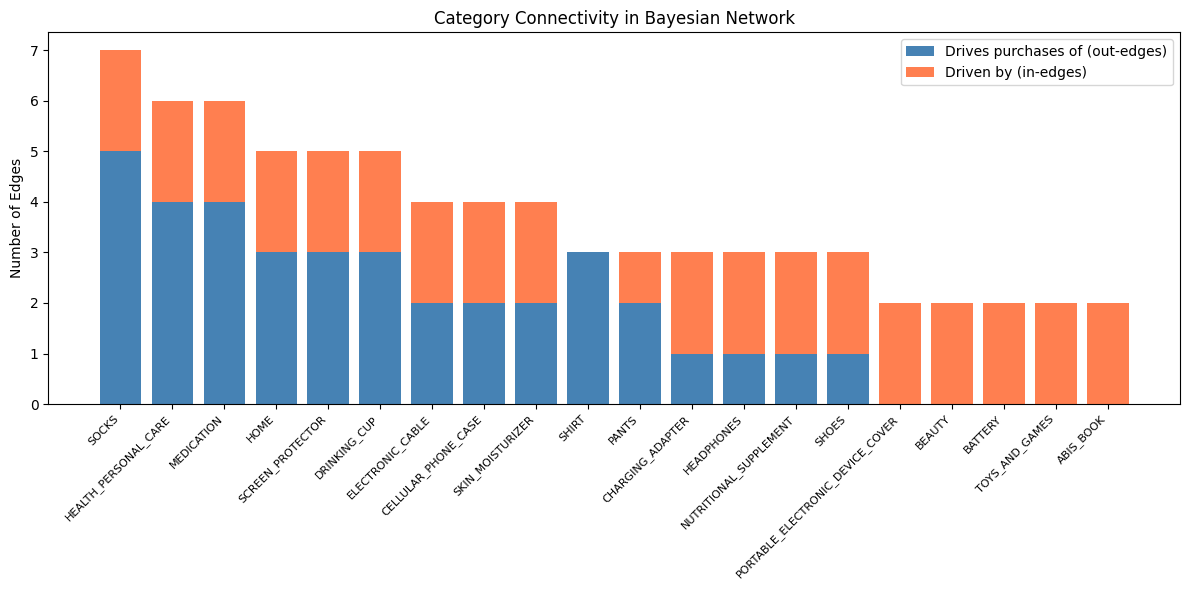

In [57]:
# Bar chart: edges per category (in-degree + out-degree)
in_deg = dict(G.in_degree())
out_deg = dict(G.out_degree())
all_nodes = sorted(G.nodes(), key=lambda n: G.degree(n), reverse=True)

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(all_nodes))
bars_in = [in_deg[n] for n in all_nodes]
bars_out = [out_deg[n] for n in all_nodes]

ax.bar(x, bars_out, label='Drives purchases of (out-edges)', color='steelblue')
ax.bar(x, bars_in, bottom=bars_out, label='Driven by (in-edges)', color='coral')

ax.set_xticks(x)
ax.set_xticklabels(all_nodes, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Number of Edges')
ax.set_title('Category Connectivity in Bayesian Network')
ax.legend()
plt.tight_layout()
plt.show()